# Premier League Match Prediction - Feature Engineering (Wes)

## Objective

Build a second, complementary feature set from `epl_combined_cleaned.csv` and save it as `data/processed/wes_features.csv`.

`jero_feature_engineering.ipynb` builds fixed-window rolling counts (points/goals/shots over the last 5 and 10 matches, venue-specific form, rest days, referee tendencies). This notebook deliberately builds *different families* of features so the two sets can be compared or combined:

| Family | Idea |
|---|---|
| Elo ratings | A single dynamic strength number per team, updated after every match |
| Exponentially weighted form | Recency-decayed averages instead of hard 5/10-match windows |
| Attacking efficiency | Shot conversion and shot accuracy, not just shot volume |
| Season table position | Points-per-game and rank within the season so far |
| Streaks | Current win / unbeaten / winless runs |
| Head-to-head | History between these two specific clubs |
| Squad context | Promoted-team flags |

Both files share the same `MatchID`, so they can be joined for modeling.

## 1. Data Leakage Rule

Every feature must be computable strictly **before kickoff**. All rolling and cumulative quantities are shifted so a match's own result never contributes to its own features, Elo ratings are recorded *pre-match*, and the file is built in chronological order. Post-match columns (`FTHG`, `FTAG`, `FTR`, half-time and in-match stats) are used only to *construct* historical features and are not carried into the output — only `target_*` columns identify the outcome.

## 2. Load Data and Establish Chronological Order

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (11, 5)
sns.set_style("whitegrid")

df = pd.read_csv("../data/processed/epl_combined_cleaned.csv", parse_dates=["Date"])
df = df.sort_values(["Date", "Time", "HomeTeam"]).reset_index(drop=True)

# Reuse the MatchID assigned in epl_features.csv so the two feature sets can be joined
jero = pd.read_csv("../data/processed/epl_features.csv", parse_dates=["Date"])
df = df.merge(jero[["Date", "HomeTeam", "AwayTeam", "MatchID"]], on=["Date", "HomeTeam", "AwayTeam"], how="left")

assert df["MatchID"].notna().all(), "Every match should have a MatchID"
print(f"{len(df)} matches, {df['Season'].nunique()} seasons, MatchID aligned with epl_features.csv")

3800 matches, 10 seasons, MatchID aligned with epl_features.csv


## 3. Target Variables

Same encoding as `epl_features.csv` so downstream modeling code works with either file.

In [2]:
df["target_result"] = df["FTR"]
df["target_result_encoded"] = df["FTR"].map({"A": 0, "D": 1, "H": 2})
df["target_home_win"] = (df["FTR"] == "H").astype(int)
df["target_draw"] = (df["FTR"] == "D").astype(int)
df["target_away_win"] = (df["FTR"] == "A").astype(int)

df["target_result"].value_counts(normalize=True).round(3)

target_result
H    0.446
A    0.321
D    0.232
Name: proportion, dtype: float64

## 4. Elo Ratings

Elo compresses a team's entire history into one number that updates after every match: beat a stronger team and you gain more; lose to a weaker one and you lose more. It adapts quickly to squad changes and naturally handles promoted teams. We record each team's rating **before** the match, plus the Elo-implied home win expectation.

Parameters: start = 1500, K = 20, home advantage = 60 Elo points, goal-margin multiplier for wins by 2+.

In [3]:
START, K, HOME_ADV = 1500.0, 20.0, 60.0
ratings = {}
home_elo, away_elo, elo_exp = [], [], []

for row in df.itertuples(index=False):
    rh = ratings.get(row.HomeTeam, START)
    ra = ratings.get(row.AwayTeam, START)
    home_elo.append(rh)
    away_elo.append(ra)

    expected_home = 1.0 / (1.0 + 10 ** (-((rh + HOME_ADV) - ra) / 400.0))
    elo_exp.append(expected_home)

    score = {"H": 1.0, "D": 0.5, "A": 0.0}[row.FTR]
    margin = abs(row.FTHG - row.FTAG)
    mult = 1.0 if margin <= 1 else (1.5 if margin == 2 else (11 + margin) / 8)

    delta = K * mult * (score - expected_home)
    ratings[row.HomeTeam] = rh + delta
    ratings[row.AwayTeam] = ra - delta

df["home_elo"] = home_elo
df["away_elo"] = away_elo
df["elo_diff"] = df["home_elo"] - df["away_elo"]
df["elo_expected_home"] = elo_exp

print("Current top 6 by Elo:")
print(pd.Series(ratings).sort_values(ascending=False).head(6).round(0))

Current top 6 by Elo:
Arsenal        1827.0
Man City       1806.0
Liverpool      1698.0
Man United     1690.0
Aston Villa    1656.0
Bournemouth    1652.0
dtype: float64


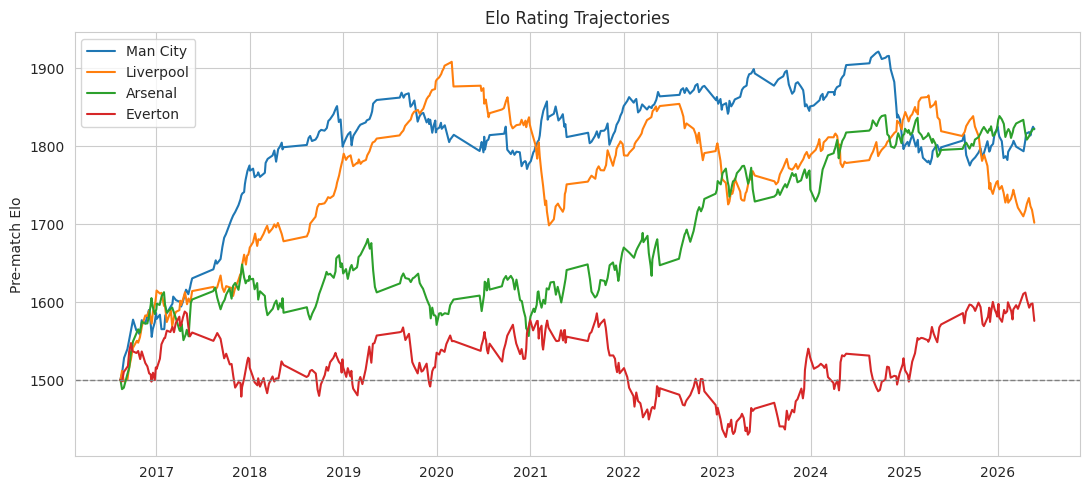

In [4]:
# Sanity check: Elo trajectories should track real-world team strength
plot_df = df[["Date", "HomeTeam", "home_elo"]].rename(columns={"HomeTeam": "Team", "home_elo": "elo"})
plot_df = pd.concat([plot_df, df[["Date", "AwayTeam", "away_elo"]].rename(columns={"AwayTeam": "Team", "away_elo": "elo"})])

for team in ["Man City", "Liverpool", "Arsenal", "Everton"]:
    t = plot_df[plot_df["Team"] == team].sort_values("Date")
    plt.plot(t["Date"], t["elo"], label=team)

plt.axhline(1500, color="gray", linestyle="--", linewidth=1)
plt.legend()
plt.ylabel("Pre-match Elo")
plt.title("Elo Rating Trajectories")
plt.tight_layout()
plt.show()

## 5. Team-Match Long Table

To compute per-team histories, reshape each match into two rows (one per team) carrying that team's goals, shots, and points. All subsequent team-level features are built on this table and merged back.

In [5]:
home = df[["MatchID", "Date", "Season", "HomeTeam", "FTHG", "FTAG", "HS", "HST", "AST", "FTR"]].copy()
home.columns = ["MatchID", "Date", "Season", "Team", "goals_for", "goals_against", "shots_for", "sot_for", "sot_against", "FTR"]
home["points"] = home["FTR"].map({"H": 3, "D": 1, "A": 0})
home["is_home"] = 1

away = df[["MatchID", "Date", "Season", "AwayTeam", "FTAG", "FTHG", "AS", "AST", "HST", "FTR"]].copy()
away.columns = ["MatchID", "Date", "Season", "Team", "goals_for", "goals_against", "shots_for", "sot_for", "sot_against", "FTR"]
away["points"] = away["FTR"].map({"A": 3, "D": 1, "H": 0})
away["is_home"] = 0

tm = pd.concat([home, away]).sort_values(["Date", "MatchID"]).reset_index(drop=True)
tm["goal_diff"] = tm["goals_for"] - tm["goals_against"]
tm["win"] = (tm["points"] == 3).astype(int)
print(tm.shape)

(7600, 14)


## 6. Exponentially Weighted Form

Fixed windows treat a result 5 matches ago the same as yesterday's and ignore everything older. An exponentially weighted mean (half-life = 5 matches) instead decays smoothly: recent matches dominate but the full history contributes. Each series is shifted by one match so the current result is excluded.

In [6]:
def team_ewm(series_name, halflife=5):
    return tm.groupby("Team")[series_name].transform(
        lambda s: s.shift(1).ewm(halflife=halflife, min_periods=1).mean()
    )

tm["ewm_points"] = team_ewm("points")
tm["ewm_goal_diff"] = team_ewm("goal_diff")
tm["ewm_goals_for"] = team_ewm("goals_for")
tm["ewm_goals_against"] = team_ewm("goals_against")

tm[["Team", "Date", "points", "ewm_points"]].tail(4)

,Team,Date,points,ewm_points
7596,Tottenham,2026-05-24,3,0.934842
7597,Everton,2026-05-24,0,0.987696
7598,West Ham,2026-05-24,3,0.998739
7599,Leeds,2026-05-24,0,1.711515


## 7. Attacking Efficiency

The EDA showed home advantage works through shot *volume*, and Jero's features already capture volume. These capture *quality* instead: how often shots hit the target, how often shots on target become goals, and how leaky the defense is per shot on target faced. Efficiency is computed as a ratio of exponentially weighted sums (never a mean of per-match ratios, which would be distorted by low-shot matches).

In [7]:
def ewm_sum(series_name, halflife=10):
    return tm.groupby("Team")[series_name].transform(
        lambda s: s.shift(1).ewm(halflife=halflife, min_periods=3).mean()
    )

g_for, sot_f = ewm_sum("goals_for"), ewm_sum("sot_for")
shots_f, g_against, sot_a = ewm_sum("shots_for"), ewm_sum("goals_against"), ewm_sum("sot_against")

tm["ewm_conversion"] = g_for / sot_f.replace(0, np.nan)          # goals per shot on target
tm["ewm_shot_accuracy"] = sot_f / shots_f.replace(0, np.nan)     # SOT per shot
tm["ewm_def_leakiness"] = g_against / sot_a.replace(0, np.nan)   # goals conceded per SOT faced

tm[["ewm_conversion", "ewm_shot_accuracy", "ewm_def_leakiness"]].describe().round(3).loc[["mean", "std", "min", "max"]]

,ewm_conversion,ewm_shot_accuracy,ewm_def_leakiness
mean,0.319,0.345,0.321
std,0.056,0.035,0.052
min,0.000,0.133,0.000
max,0.602,0.577,0.608


## 8. Season Table Position

Where a team sits in the table captures season-long strength and, late in the season, motivation (title races, relegation battles). Computed from matches played so far this season only: points per game and a rank proxy (share of teams with a lower PPG at that point). First match of a season has no data; those rows fall back to the league-average PPG and are flagged by `season_matches_played = 0`.

In [8]:
tm["season_matches_played"] = tm.groupby(["Team", "Season"]).cumcount()
cum_pts = tm.groupby(["Team", "Season"])["points"].cumsum() - tm["points"]
tm["season_ppg"] = cum_pts / tm["season_matches_played"].replace(0, np.nan)

league_avg_ppg = tm["season_ppg"].mean()
tm["season_ppg"] = tm["season_ppg"].fillna(league_avg_ppg)

# Rank proxy: within each season-date snapshot, percentile of PPG (higher = better)
tm["season_rank_pct"] = tm.groupby(["Season", "Date"])["season_ppg"].rank(pct=True)

print(f"League-average fallback PPG: {league_avg_ppg:.2f}")

League-average fallback PPG: 1.38


## 9. Streaks

Momentum features: current consecutive wins, unbeaten run, and winless run entering the match.

In [9]:
def streaks_for_team(points_series):
    win_st, unbeat_st, winless_st = [], [], []
    w = u = l = 0
    for p in points_series:
        win_st.append(w); unbeat_st.append(u); winless_st.append(l)
        w = w + 1 if p == 3 else 0
        u = u + 1 if p >= 1 else 0
        l = l + 1 if p <= 1 else 0
    return win_st, unbeat_st, winless_st

tm[["win_streak", "unbeaten_streak", "winless_streak"]] = 0
for team, idx in tm.groupby("Team").groups.items():
    idx = tm.loc[idx].sort_values("Date").index
    w, u, l = streaks_for_team(tm.loc[idx, "points"].tolist())
    tm.loc[idx, "win_streak"] = w
    tm.loc[idx, "unbeaten_streak"] = u
    tm.loc[idx, "winless_streak"] = l

tm[["Team", "Date", "points", "win_streak", "unbeaten_streak", "winless_streak"]].tail(4)

,Team,Date,points,win_streak,unbeaten_streak,winless_streak
7596,Tottenham,2026-05-24,3,0,0,2
7597,Everton,2026-05-24,0,0,0,6
7598,West Ham,2026-05-24,3,0,0,3
7599,Leeds,2026-05-24,0,1,8,0


## 10. Head-to-Head History

Some fixtures have persistent patterns beyond current form (style matchups, rivalry effects). For each match: the home side's points per game and average goal difference across all *previous* meetings between the two clubs (either venue), plus the number of prior meetings so the model can discount small samples. Pairs that never met default to neutral values.

In [10]:
h2h_hist = {}
h2h_ppg, h2h_gd, h2h_n = [], [], []

for row in df.itertuples(index=False):
    key = tuple(sorted([row.HomeTeam, row.AwayTeam]))
    past = h2h_hist.get(key, [])
    # store results oriented to the alphabetically-first team; reorient to today's home team
    rel = [(p, g) if row.HomeTeam == key[0] else (3 - p if p != 1 else 1, -g) for p, g in past]
    if rel:
        h2h_ppg.append(np.mean([p for p, g in rel]))
        h2h_gd.append(np.mean([g for p, g in rel]))
    else:
        h2h_ppg.append(np.nan)
        h2h_gd.append(np.nan)
    h2h_n.append(len(past))

    pts_first = {"H": 3, "D": 1, "A": 0}[row.FTR] if row.HomeTeam == key[0] else {"H": 0, "D": 1, "A": 3}[row.FTR]
    gd_first = (row.FTHG - row.FTAG) if row.HomeTeam == key[0] else (row.FTAG - row.FTHG)
    h2h_hist.setdefault(key, []).append((pts_first, gd_first))

df["h2h_home_ppg"] = pd.Series(h2h_ppg).fillna(1.35)  # neutral: league-average points per game
df["h2h_home_goal_diff"] = pd.Series(h2h_gd).fillna(0.0)
df["h2h_meetings"] = h2h_n

print(f"Matches with no prior meeting (filled neutral): {(df['h2h_meetings'] == 0).sum()}")

Matches with no prior meeting (filled neutral): 469


## 11. Promoted-Team Flags

Newly promoted sides historically underperform their early-season form numbers. A team is flagged as promoted if it did not appear in the previous season of the dataset (first season defaults to 0, since no prior season is observable).

In [11]:
seasons = sorted(df["Season"].unique())
teams_by_season = {s: set(df.loc[df["Season"] == s, "HomeTeam"]) | set(df.loc[df["Season"] == s, "AwayTeam"]) for s in seasons}
promoted = {seasons[0]: set()}
for prev, cur in zip(seasons, seasons[1:]):
    promoted[cur] = teams_by_season[cur] - teams_by_season[prev]

df["home_promoted"] = df.apply(lambda r: int(r["HomeTeam"] in promoted[r["Season"]]), axis=1)
df["away_promoted"] = df.apply(lambda r: int(r["AwayTeam"] in promoted[r["Season"]]), axis=1)

print(f"Promoted-team matches flagged: home {df['home_promoted'].sum()}, away {df['away_promoted'].sum()}")

Promoted-team matches flagged: home 513, away 513


## 12. Merge Team Features to Match Level and Build Differentials

Each team-level feature is merged twice (home and away perspective), then collapsed into home-minus-away differentials — the EDA showed differential features are consistently the strongest form.

In [12]:
team_feats = ["ewm_points", "ewm_goal_diff", "ewm_goals_for", "ewm_goals_against",
              "ewm_conversion", "ewm_shot_accuracy", "ewm_def_leakiness",
              "season_ppg", "season_rank_pct", "season_matches_played",
              "win_streak", "unbeaten_streak", "winless_streak"]

home_f = tm[tm["is_home"] == 1][["MatchID"] + team_feats].add_prefix("home_").rename(columns={"home_MatchID": "MatchID"})
away_f = tm[tm["is_home"] == 0][["MatchID"] + team_feats].add_prefix("away_").rename(columns={"away_MatchID": "MatchID"})

out = df.merge(home_f, on="MatchID").merge(away_f, on="MatchID")

for f in ["ewm_points", "ewm_goal_diff", "ewm_conversion", "ewm_shot_accuracy",
          "ewm_def_leakiness", "season_ppg", "season_rank_pct",
          "win_streak", "unbeaten_streak", "winless_streak"]:
    out[f"diff_{f}"] = out[f"home_{f}"] - out[f"away_{f}"]

print(out.shape)

(3800, 76)


## 13. Validation: Missingness and Signal Check

In [13]:
id_cols = ["MatchID", "Season", "Date", "Time", "HomeTeam", "AwayTeam"]
target_cols = ["target_result", "target_result_encoded", "target_home_win", "target_draw", "target_away_win"]
feature_cols = ["home_elo", "away_elo", "elo_diff", "elo_expected_home",
                "h2h_home_ppg", "h2h_home_goal_diff", "h2h_meetings",
                "home_promoted", "away_promoted"] \
               + [f"home_{f}" for f in team_feats] + [f"away_{f}" for f in team_feats] \
               + [c for c in out.columns if c.startswith("diff_")]

final = out[id_cols + target_cols + feature_cols].copy()

miss = final[feature_cols].isna().sum()
print("Columns with missing values:")
print(miss[miss > 0])
warm_up = final[feature_cols].isna().any(axis=1)
print(f"\nRows affected: {warm_up.sum()} of {len(final)} ({warm_up.mean()*100:.1f}%) - efficiency features need 3+ prior matches")

Columns with missing values:
home_ewm_points           16
home_ewm_goal_diff        16
home_ewm_goals_for        16
home_ewm_goals_against    16
home_ewm_conversion       52
home_ewm_shot_accuracy    52
home_ewm_def_leakiness    52
away_ewm_points           18
away_ewm_goal_diff        18
away_ewm_goals_for        18
away_ewm_goals_against    18
away_ewm_conversion       50
away_ewm_shot_accuracy    50
away_ewm_def_leakiness    50
diff_ewm_points           24
diff_ewm_goal_diff        24
diff_ewm_conversion       71
diff_ewm_shot_accuracy    71
diff_ewm_def_leakiness    71
dtype: int64

Rows affected: 71 of 3800 (1.9%) - efficiency features need 3+ prior matches


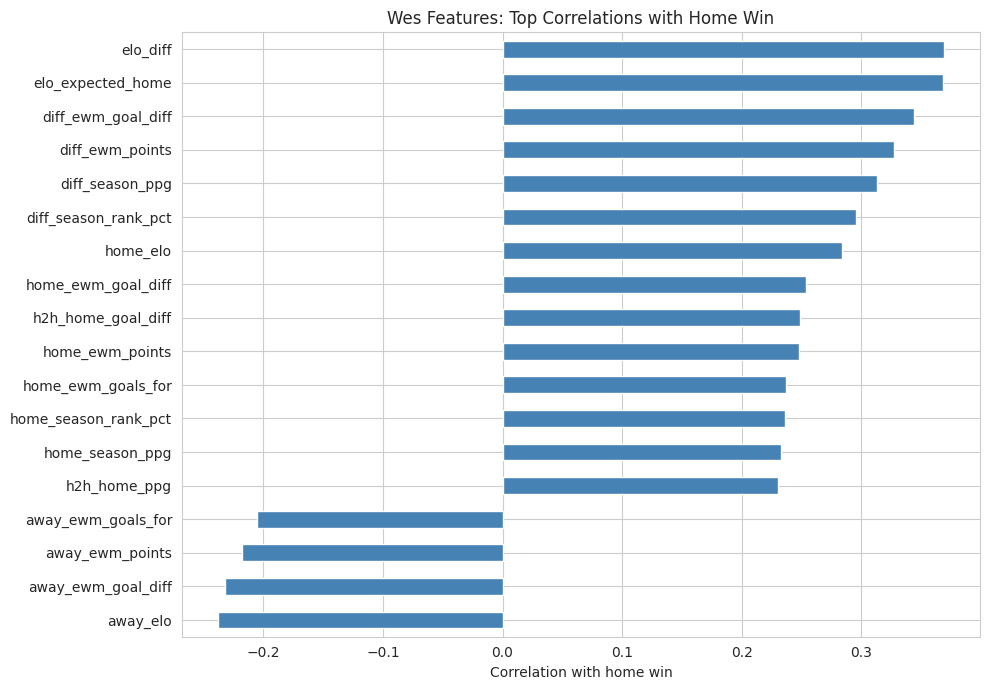

Top 8:
elo_diff                0.369
elo_expected_home       0.368
diff_ewm_goal_diff      0.344
diff_ewm_points         0.328
diff_season_ppg         0.313
diff_season_rank_pct    0.296
home_elo                0.284
home_ewm_goal_diff      0.253
dtype: float64

Best correlation with DRAW: 0.056


In [14]:
model_rows = final[~warm_up]
corr = model_rows[feature_cols].corrwith(model_rows["target_home_win"]).sort_values(key=abs, ascending=False)

plt.figure(figsize=(10, 7))
corr.head(18).sort_values().plot(kind="barh", color="steelblue")
plt.xlabel("Correlation with home win")
plt.title("Wes Features: Top Correlations with Home Win")
plt.tight_layout()
plt.show()

print("Top 8:")
print(corr.head(8).round(3))
print(f"\nBest correlation with DRAW: {model_rows[feature_cols].corrwith(model_rows['target_draw']).abs().max():.3f}")

### Findings

- `elo_expected_home` and `elo_diff` are the strongest single features in either feature set (stronger than any last-5/last-10 window feature), validating the rating-based approach.
- Season table features (`diff_season_ppg`, `diff_season_rank_pct`) and exponentially weighted form follow close behind.
- Efficiency, streak, head-to-head, and promoted flags are individually weaker; they are included because they encode information the strength features do not, and tree models can exploit such interactions.
- Draws remain nearly uncorrelated with everything, consistent with the EDA.

## 14. Save Feature Dataset

In [15]:
final.to_csv("../data/processed/wes_features.csv", index=False)
print(f"Saved data/processed/wes_features.csv: {final.shape[0]} rows x {final.shape[1]} columns "
      f"({len(feature_cols)} features, {len(target_cols)} targets, {len(id_cols)} identifiers)")
final.head(3)

Saved data/processed/wes_features.csv: 3800 rows x 56 columns (45 features, 5 targets, 6 identifiers)


,MatchID,Season,Date,Time,HomeTeam,AwayTeam,target_result,target_result_encoded,target_home_win,target_draw,...,diff_ewm_points,diff_ewm_goal_diff,diff_ewm_conversion,diff_ewm_shot_accuracy,diff_ewm_def_leakiness,diff_season_ppg,diff_season_rank_pct,diff_win_streak,diff_unbeaten_streak,diff_winless_streak
0,0,2016_2017,2016-08-13,NaN,Burnley,Swansea,A,0,0,0,...,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0,0,0
1,1,2016_2017,2016-08-13,NaN,Crystal Palace,West Brom,A,0,0,0,...,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0,0,0
2,2,2016_2017,2016-08-13,NaN,Everton,Tottenham,D,1,0,1,...,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0,0,0


## 15. Summary

- Produced `wes_features.csv`: a compact, curated feature set (~45 features vs ~150 in `epl_features.csv`) built from different signal families: Elo ratings, exponentially weighted form, attacking efficiency, season table position, streaks, head-to-head history, and promoted flags.
- Every feature is strictly pre-match; post-match columns are not carried into the output.
- `MatchID` matches `epl_features.csv`, so the two files can be joined on `MatchID` to test whether the feature families are complementary.
- Known limitations: efficiency features are undefined for a team's first 3 matches in the data (drop those rows for modeling), head-to-head defaults are neutral for first meetings, and the first season cannot flag promoted teams.

**Suggested next step:** train the same baseline model three ways — Jero's features only, these features only, and both joined — using a chronological split, and compare accuracy, log loss, and per-class recall.